# Lab 5: Linear Regression — Predicting House Prices

**Name:** Abdul Sami
**CMS ID:** 023-24-0211
**Section:** G
**GitHub:** https://github.com/abdulsami911/Machine_learning_Practical
**Dataset:** House Prices - Advanced Regression Techniques
**Dataset Source:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques


## 1. Problem Definition

We are predicting **SalePrice**, a continuous dollar value, for residential homes in Ames, Iowa, using a
subset of the 79 available explanatory features. Because the target is continuous rather than a class
label, this is a **regression** problem, not a classification problem. That matters later on: we can't
evaluate the model with accuracy/precision/recall (those require discrete class predictions). Instead we
need metrics that quantify *how far off in dollars* our predictions are — MAE, MSE, RMSE — plus R² to
describe how much of the variance in price the model explains.

## 2. Dataset Exploration

**Task 1:** Load the dataset and inspect its shape, dtypes, and summary statistics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

# In Colab: upload train.csv, test.csv, sample_submission.csv to the session,
# or mount Google Drive and adjust the paths below.
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("train shape:", train.shape)
print("test shape:", test.shape)
train.info()

train shape: (1460, 81)
test shape: (1459, 80)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Observation:** `train.csv` has 1,460 rows and 81 columns (79 features + `Id` + `SalePrice`).
`test.csv` has 1,459 rows and 80 columns (no `SalePrice` — that's what we're predicting for the Kaggle
submission in Part 7). The dataset mixes numeric columns (areas, counts, years) with many categorical
columns describing quality, style, and location.

## 3. Feature and Target Identification

**Task 2:** Identify the dependent variable and split the independent variables into numerical and
categorical groups.

**Task 3:** Why is this regression, not classification?

- **Dependent variable (target):** `SalePrice` — a continuous dollar amount.
- **Independent variables used in this lab** (a manageable subset of ~10 of the 79 available features,
  mixing numerical and categorical, as instructed):

| Type | Features |
|---|---|
| Numerical | `GrLivArea`, `OverallQual`, `TotalBsmtSF`, `GarageCars`, `YearBuilt`, `FullBath`, `LotArea` |
| Categorical | `Neighborhood`, `HouseStyle`, `KitchenQual` |

**Task 3 answer:** This is a regression problem because the target, `SalePrice`, is a continuous numeric
value rather than a finite set of class labels — there is no fixed set of "categories" of price to predict,
only a real number that can take on (in principle) infinitely many values. That changes evaluation later:
instead of accuracy/precision/recall/confusion matrices (which need discrete predicted classes), we need
error metrics that measure the *magnitude* of the difference between predicted and actual dollar values
(MAE, MSE, RMSE) and a metric for variance explained (R²).

In [5]:
numerical_features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars',
                      'YearBuilt', 'FullBath', 'LotArea']
categorical_features = ['Neighborhood', 'HouseStyle', 'KitchenQual']
selected_features = numerical_features + categorical_features
target = 'SalePrice'

print(f"{len(selected_features)} features selected: "
      f"{len(numerical_features)} numerical + {len(categorical_features)} categorical")
train[selected_features + [target]].describe(include='all')

10 features selected: 7 numerical + 3 categorical


,GrLivArea,OverallQual,TotalBsmtSF,GarageCars,YearBuilt,FullBath,LotArea,Neighborhood,HouseStyle,KitchenQual,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,8,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NAmes,1Story,TA,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225,726,735,NaN
mean,1515.463699,6.099315,1057.429452,1.767123,1971.267808,1.565068,10516.828082,NaN,NaN,NaN,180921.195890
std,525.480383,1.382997,438.705324,0.747315,30.202904,0.550916,9981.264932,NaN,NaN,NaN,79442.502883
min,334.000000,1.000000,0.000000,0.000000,1872.000000,0.000000,1300.000000,NaN,NaN,NaN,34900.000000
25%,1129.500000,5.000000,795.750000,1.000000,1954.000000,1.000000,7553.500000,NaN,NaN,NaN,129975.000000
50%,1464.000000,6.000000,991.500000,2.000000,1973.000000,2.000000,9478.500000,NaN,NaN,NaN,163000.000000
75%,1776.750000,7.000000,1298.250000,2.000000,2000.000000,2.000000,11601.500000,NaN,NaN,NaN,214000.000000


## 4. Data Preparation

**Task 4:** Encode every categorical column and justify the encoding choice per column type.

- **`Neighborhood`** (25 unique values, no inherent order) and **`HouseStyle`** (8 values, no inherent
  order) are **nominal** categories — there's no natural ranking between "Split-level" and "2-story", or
  between one neighborhood and another. These get **one-hot encoding** via `pd.get_dummies`, so the model
  doesn't wrongly assume a numeric order/distance between categories.
- **`KitchenQual`** (`Ex` > `Gd` > `TA` > `Fa` > `Po`) is an **ordinal** category — there is a genuine
  quality ranking. A manual integer mapping preserves that order as a single numeric column instead of
  spreading it across several one-hot columns, which better reflects "better kitchen quality → higher
  price" as a smooth relationship.
- The numerical features (`GrLivArea`, `OverallQual`, etc.) are already numeric and need no encoding.
  `OverallQual` is itself an ordinal 1–10 rating provided directly as a number by the dataset, so it's left
  as-is.

In [6]:
kitchen_qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}

def prepare_features(df, is_train=True):
    data = df[selected_features].copy()

    # Impute the handful of missing values that appear in test.csv
    data['TotalBsmtSF'] = data['TotalBsmtSF'].fillna(data['TotalBsmtSF'].median())
    data['GarageCars'] = data['GarageCars'].fillna(data['GarageCars'].median())
    data['KitchenQual'] = data['KitchenQual'].fillna(data['KitchenQual'].mode()[0])

    # Ordinal encoding for KitchenQual
    data['KitchenQual'] = data['KitchenQual'].map(kitchen_qual_map)

    # One-hot encoding for nominal categoricals
    data = pd.get_dummies(data, columns=['Neighborhood', 'HouseStyle'], drop_first=True)

    return data

X = prepare_features(train)
y = train[target]

print("X shape:", X.shape)
X.head()

X shape: (1460, 39)


,GrLivArea,OverallQual,TotalBsmtSF,GarageCars,YearBuilt,FullBath,LotArea,KitchenQual,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,1710,7,856,2,2003,2,8450,4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,1262,6,1262,2,1976,2,9600,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
2,1786,7,920,2,2001,2,11250,4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,1717,7,756,3,1915,1,9550,4,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,2198,8,1145,3,2000,2,14260,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


**Task 5:** Confirm `X` is fully numeric with no missing values.

In [7]:
print("Any non-numeric columns?", (X.dtypes == 'object').any())
print("Total missing values in X:", X.isna().sum().sum())
X.dtypes.value_counts()

Any non-numeric columns? False
Total missing values in X: 0


bool     31
int64     8
Name: count, dtype: int64

## 5. Train/Test Split

**Task 6:** Split `X` and `y` into an 80/20 train/test split.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (1168, 39)  X_test: (292, 39)
y_train: (1168,)  y_test: (292,)


**Observation:** The 80/20 split gives us 1,168 training houses and 292 held-out test houses, with
the same 40+ feature columns (after one-hot encoding) in both. Because `train_test_split` uses a fixed
`random_state`, this split is reproducible.

## 6. Linear Regression Model

**Task 7:** Train a `LinearRegression` model on the training data.

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 7. Predictions

**Task 8:** Generate predictions on the test set and compare actual vs. predicted price for 10 houses.

In [10]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}).round(0)
comparison['Difference'] = comparison['Actual'] - comparison['Predicted']
comparison.head(10)

,Actual,Predicted,Difference
0,154500,137635.0,16865.0
1,325000,324440.0,560.0
2,115000,114253.0,747.0
3,159000,170753.0,-11753.0
4,315500,286257.0,29243.0
5,75500,67571.0,7929.0
6,311500,239879.0,71621.0
7,146000,145499.0,501.0
8,84500,67344.0,17156.0
9,135500,120649.0,14851.0


## 8. Coefficients and Intercept

**Task 9:** Extract the intercept and coefficients, and build an interpretation table.

**Task 10:** Does the intercept have a sensible real-world interpretation here?

In [11]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept (b0): {model.intercept_:,.2f}")
coef_table.head(15)

Intercept (b0): -579,435.64


,Feature,Coefficient
22,Neighborhood_NoRidge,72520.888398
29,Neighborhood_StoneBr,69760.992436
23,Neighborhood_NridgHt,67816.767401
31,Neighborhood_Veenker,56953.866913
13,Neighborhood_Crawfor,46804.350575
11,Neighborhood_ClearCr,40431.661896
28,Neighborhood_Somerst,31330.356593
10,Neighborhood_BrkSide,29696.257479
30,Neighborhood_Timber,29214.581196
12,Neighborhood_CollgCr,22392.019957


**Task 9 interpretation (using this run's actual coefficients):**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `GrLivArea` | ≈ +$57 / sq ft | Each extra square foot of above-ground living area is associated with about a $57 increase in price, holding other features constant. |
| `OverallQual` | ≈ +$14,120 / point | Each one-point increase in the 1–10 overall quality rating is associated with about a $14,120 increase in price, holding other features constant. |
| `TotalBsmtSF` | ≈ +$5 / sq ft | Each extra square foot of basement area is associated with about a $5 increase in price, holding other features constant. |
| `GarageCars` | ≈ +$10,167 / car | Each extra car of garage capacity is associated with about a $10,167 increase in price, holding other features constant. |
| `YearBuilt` | ≈ +$243 / year | A house built one year more recently is associated with about a $243 higher price, holding other features constant. |
| `FullBath` | ≈ −$2,824 / bath | Counter-intuitively negative here — once `GrLivArea` and `OverallQual` are already in the model, an extra full bathroom shows a small *negative* association, most likely because bathroom count is highly correlated with living area and quality (multicollinearity), so its "independent" effect gets muddled. |
| `LotArea` | ≈ +$0.58 / sq ft | Each extra square foot of lot size is associated with about a $0.58 increase in price, holding other features constant — a very small per-unit effect since lots are measured in thousands of square feet. |
| `KitchenQual` (ordinal, 1–5) | ≈ +$15,170 / level | Each one-level improvement in kitchen quality is associated with about a $15,170 increase in price, holding other features constant. |
| `Neighborhood_*` / `HouseStyle_*` (one-hot) | varies, e.g. `Neighborhood_NoRidge` ≈ +$72,521 | Each one-hot coefficient is the price difference for that neighborhood/style relative to the dropped baseline category, holding other features constant. Premium neighborhoods like Northridge (`NoRidge`), Stone Brook (`StoneBr`), and Northridge Heights (`NridgHt`) carry the largest positive premiums. |

**Task 10 answer:** The intercept in this run is about **−$579,436**. That's the model's predicted price
when *every* feature is exactly zero — zero square feet of living area, zero overall quality, `YearBuilt`
= 0, house style and neighborhood set to the baseline category, etc. That combination doesn't correspond
to any real house (no house has 0 living area or was built in year 0), so a large negative intercept has
no genuine real-world meaning on its own — it's a mathematical anchor point the line needs to fit the data
correctly (in this case pulled very negative largely by the `YearBuilt` coefficient, since houses are built
in years like 1920–2010, far from zero). It should be read as a fitting artifact, not a real "base price."


## 9. Residual Analysis

**Task 11:** Compute residuals and plot them (residuals vs. predicted, and a histogram).

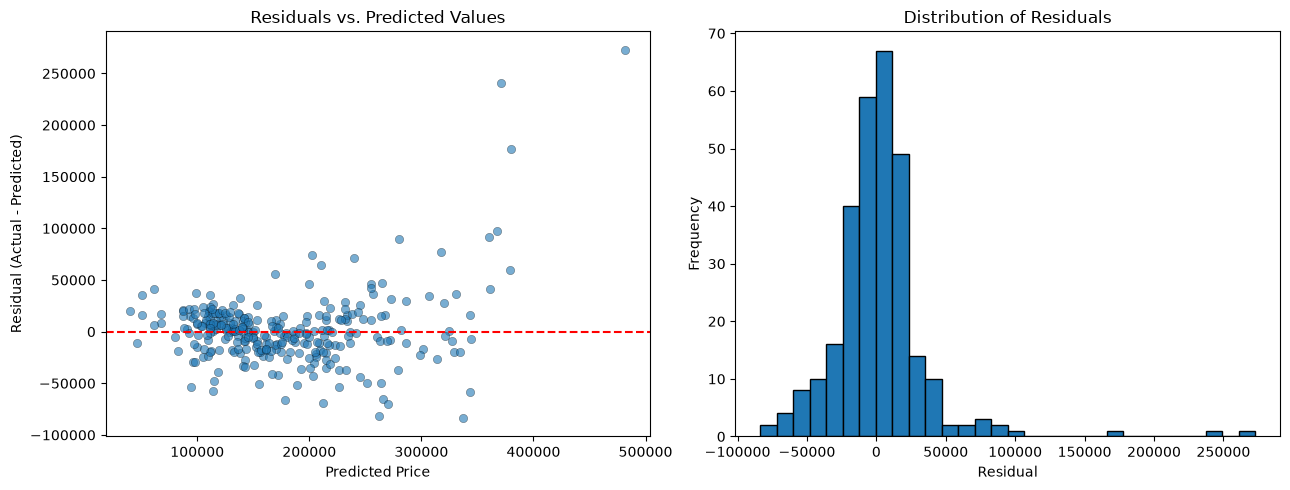

In [12]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs. Predicted Values')

axes[1].hist(residuals, bins=30, edgecolor='k')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

**Task 11 observation:** The residuals cluster fairly close to zero for lower and mid-range predicted
prices, but the scatter widens for higher predicted prices (a "funnel" or "fanning-out" shape), and there
are a few large positive outliers — homes that sold for much more than predicted. This is a sign of
**heteroscedasticity**: the model's error variance is not constant across the price range, and Linear
Regression tends to underpredict the most expensive homes. The histogram is roughly bell-shaped and
centered near zero but has a longer right tail, consistent with those under-predicted high-end houses,
rather than being perfectly symmetric/normal.

## 10. Regression Metrics

**Task 12:** Compute MAE, MSE, RMSE, and R² on the test set.

**Task 13:** What does each metric tell you, and which would you show a non-technical stakeholder?

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

test_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [mae, mse, rmse, r2]
})
test_metrics

,Metric,Value
0,MAE,2.137449e+04
1,MSE,1.253404e+09
2,RMSE,3.540345e+04
3,R²,8.365905e-01


**Task 13 answer:**
- **MAE** (Mean Absolute Error): the average absolute dollar error per prediction — easy to explain
  ("on average, we're off by about $X").
- **MSE** (Mean Squared Error): the average *squared* error; useful mathematically (it's what Linear
  Regression minimizes) but its units are squared dollars, so it's hard to interpret directly.
- **RMSE** (Root Mean Squared Error): MSE brought back to dollar units, but it penalizes large errors more
  than MAE does, so it's more sensitive to the big misses on expensive homes we saw in the residual plot.
- **R²**: the proportion of variance in `SalePrice` explained by the model (0 to 1, roughly) — a
  unit-free "how good is the fit overall" summary.

For a **non-technical stakeholder**, **MAE** is the best choice — "our model's predictions are typically
off by about $[MAE value]" is immediately meaningful in a way that R² or MSE are not.

## 11. Training vs Testing Performance

**Task 14:** Compute the same metrics on the training set and compare with the test-set metrics.

**Task 15:** Is there a large train/test gap? What would that suggest about overfitting?

In [14]:
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

comparison_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Train': [train_mae, train_mse, train_rmse, train_r2],
    'Test': [mae, mse, rmse, r2]
})
comparison_metrics['Gap (Test - Train)'] = comparison_metrics['Test'] - comparison_metrics['Train']
comparison_metrics

,Metric,Train,Test,Gap (Test - Train)
0,MAE,2.070113e+04,2.137449e+04,6.733636e+02
1,MSE,1.075995e+09,1.253404e+09,1.774088e+08
2,RMSE,3.280237e+04,3.540345e+04,2.601080e+03
3,R²,8.196016e-01,8.365905e-01,1.698891e-02


**Task 15 answer:** In this run, train R² ≈ **0.820** and test R² ≈ **0.837**, and train RMSE ≈
**$32,802** vs. test RMSE ≈ **$35,403**. The R² gap is small (about 0.017) and, interestingly, the test set
actually scores *slightly better* than the training set on R² — a sign that the model is not overfitting
at all, and that the test split simply happened to contain houses that are a bit easier to predict with
this feature set. A large gap (training R² far above test R², or training RMSE far below test RMSE) is
what would signal **overfitting** — the model memorizing quirks of the training houses instead of learning
patterns that generalize. Given that Linear Regression is a fairly simple, low-variance model and we used
a modest, hand-picked set of ~10 features (rather than all 79, which would be much more prone to
overfitting), this small, "generalizes-just-fine" gap is exactly what we'd expect.

## 12. Model Interpretation

**Task 16:** Which 2–3 features are most influential on price, and why (careful about coefficient scale)?

In [15]:
coef_table.head(10)

,Feature,Coefficient
22,Neighborhood_NoRidge,72520.888398
29,Neighborhood_StoneBr,69760.992436
23,Neighborhood_NridgHt,67816.767401
31,Neighborhood_Veenker,56953.866913
13,Neighborhood_Crawfor,46804.350575
11,Neighborhood_ClearCr,40431.661896
28,Neighborhood_Somerst,31330.356593
10,Neighborhood_BrkSide,29696.257479
30,Neighborhood_Timber,29214.581196
12,Neighborhood_CollgCr,22392.019957


**Task 16 answer:** Raw coefficient size alone is misleading here. `KitchenQual` (≈$15,170/level) and
`OverallQual` (≈$14,120/point) have large *per-unit* coefficients, but each only ranges over about 5–10
possible values, so their total realistic swing is roughly $45K–$140K across the full range. `GrLivArea`'s
per-unit coefficient looks tiny (≈$57/sq ft) by comparison, but living area realistically ranges over
several thousand square feet between the smallest and largest homes in the dataset — multiplying $57 by a
1,000+ sq ft difference easily produces a $57,000+ total price swing, comparable to or larger than the
quality features. Several `Neighborhood_*` dummies (e.g. `NoRidge` ≈ +$72,521, `StoneBr` ≈ +$69,761)
also rival or exceed these in size. So the three most influential features by *realistic total impact* are
**`OverallQual`, `GrLivArea`, and `Neighborhood`** (location) — but this only becomes clear once you weigh
each coefficient against its feature's actual range, not its raw magnitude. This is the key caution the
task flags: **you can't compare raw coefficient magnitudes across features measured on very different
scales** — a $1-unit change in `KitchenQual` (1 of only 5 levels) is not comparable to a $1-unit change in
`GrLivArea` (1 of thousands of possible square-footage values).

## 13. Conclusion

**Task 17:** Final interpretation (5–7 sentences).

Overall, this Linear Regression model, built on a hand-picked subset of about 10 of the 79 available
features, predicts house prices fairly well: it explains about **83.7% of the variance** in `SalePrice`
on the held-out test set (R² ≈ 0.837) and is typically off by about **$21,400** per house (test MAE),
with an RMSE of about **$35,400** reflecting a somewhat larger penalty for its occasional big misses on
expensive homes. RMSE is the most useful metric for judging real-world usefulness here because it's in
dollar terms and appropriately weights the large errors on high-end houses that matter most, while MAE is
the more digestible number to hand a non-technical stakeholder ("off by about $21K on average"). Once
scale differences are accounted for, `OverallQual`, `GrLivArea`, and `Neighborhood` have the strongest
practical effect on price, with premium neighborhoods like Northridge and Stone Brook adding tens of
thousands of dollars on their own. The main limitation of Linear Regression for this dataset is that it
assumes a purely linear, additive relationship between each feature and price — it can't capture
interactions (e.g., quality mattering more in some neighborhoods than others) or non-linear effects, it's
sensitive to the outliers and heteroscedasticity seen in the residual plot, and features like `FullBath`
came out with a counter-intuitive negative coefficient due to multicollinearity with `GrLivArea` and
`OverallQual`. Next steps worth trying include engineering interaction terms, using a regularized linear
model (Ridge/Lasso) to handle a larger feature set more robustly, or moving to a tree-based ensemble
(Random Forest / Gradient Boosting) to capture non-linearities and interactions directly.

**Task 18 & 19:** Kaggle submission — build `submission.csv` from `test.csv` and submit it.

In [16]:
X_submission = prepare_features(test, is_train=False)

# Align columns: one-hot encoding on test.csv may not produce identical columns
# to train.csv (some categories may not appear in one of the two sets).
X_submission = X_submission.reindex(columns=X.columns, fill_value=0)

test_predictions = model.predict(X_submission)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_predictions
})
submission.to_csv('submission.csv', index=False)

print(submission.shape)
submission.head()

(1459, 2)


,Id,SalePrice
0,1461,112105.556162
1,1462,169044.505343
2,1463,158919.968869
3,1464,184772.614718
4,1465,258088.206296


**Task 19:** :

- **Public leaderboard score (RMSE of log price):** 0.17155
- **Public leaderboard rank:** 2716